In [1]:
import numpy as np

QINV = 62209
KYBER_Q = 3329

def get_int16(t, lsb_idx):
    return int.from_bytes([t[lsb_idx], t[lsb_idx+1]], byteorder='little', signed=True)

def montgomery_reduce(a: int) -> int:
    a16 = np.int16(a & 0xFFFF) if a < 0 else np.int16(a % 2**16)
    t16 = np.int16(np.int32(a16) * QINV)
    u = np.int32(a) - np.int32(t16) * KYBER_Q
    return int(u >> 16)

def smlad(a_lo, a_hi, b_lo, b_hi):
    return int(np.int32(a_lo) * b_lo + np.int32(a_hi) * b_hi)

def smlsd(a_lo, a_hi, b_lo, b_hi):
    return int(np.int32(a_lo) * b_lo - np.int32(a_hi) * b_hi)

def HW_int32(x: np.int32) -> int:
    x = np.int32(x)
    u = x.view(np.uint32)
    return int(u).bit_count()

100%|██████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 3888.01it/s]


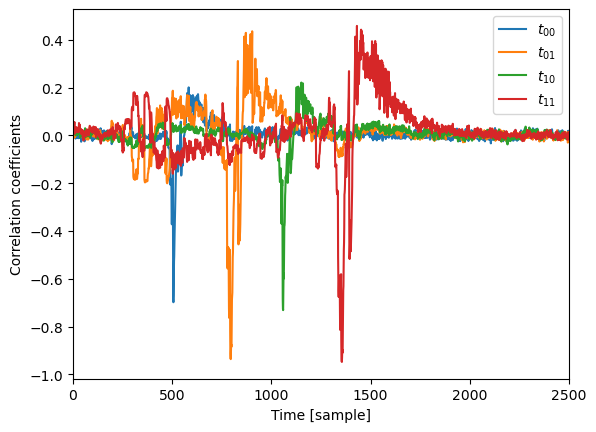

In [2]:
### Check correlations
from scaueclib import OnlineCPA
from tqdm import tqdm
import matplotlib.pyplot as plt

dim = 5000

onlineVec_acc_0 = OnlineCPA(dim)
onlineVec_acc_1 = OnlineCPA(dim)
onlineVec_acc_2 = OnlineCPA(dim)
onlineVec_acc_3 = OnlineCPA(dim)


N = 10000
for i in tqdm(range(N)):
    sample = np.load(f"./trace_masked_pairwise_mul_OPT3/sample_{i:08}.npz")
    trace = sample["trace"][:dim]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, u0, u1 = vals[:6]
    r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]
    
    zeta = np.int16(-1044) 
    u_zeta = montgomery_reduce(np.int32(zeta) * u1)
    
    acc_0 = smlad(s0_0, r0, u0, r1) + smlad(s1_0, r2, u_zeta, r3)
    acc_1 = smlad(s0_1, -r0, u0, r1) + smlad(s1_1, -r2, u_zeta, r3)
        
    acc_2 = smlad(s0_0, r4, u1, r5) + smlad(s1_0, r6, u0, r7)
    acc_3 = smlad(s0_1, -r4, u1, r5) + smlad(s1_1, -r6, u0, r7)


    onlineVec_acc_0.update(trace, HW_int32(acc_0))
    onlineVec_acc_1.update(trace, HW_int32(acc_1))
    onlineVec_acc_2.update(trace, HW_int32(acc_2))
    onlineVec_acc_3.update(trace, HW_int32(acc_3))

pearson_corr_acc0 = onlineVec_acc_0.get_pearson_corr()
pearson_corr_acc1 = onlineVec_acc_1.get_pearson_corr()
pearson_corr_acc2 = onlineVec_acc_2.get_pearson_corr()
pearson_corr_acc3 = onlineVec_acc_3.get_pearson_corr()


plt.plot(pearson_corr_acc0, label=r"$t_{00}$")
plt.plot(pearson_corr_acc1, label=r"$t_{01}$")
plt.plot(pearson_corr_acc2, label=r"$t_{10}$")
plt.plot(pearson_corr_acc3, label=r"$t_{11}$")
plt.legend()

plt.xlim(0, 2500)
plt.ylabel("Correlation coefficients")
plt.xlabel("Time [sample]")

plt.savefig("images/acc_correlations.pdf", bbox_inches='tight')

plt.show()

idx_acc0_argmin = np.argmin(pearson_corr_acc0)
idx_acc1_argmin = np.argmin(pearson_corr_acc1)
idx_acc2_argmin = np.argmin(pearson_corr_acc2)
idx_acc3_argmin = np.argmin(pearson_corr_acc3)


dtype('uint16')